In [1]:
from pathlib import Path
from os import environ

ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixpoisson")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/rlct")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/rlct


In [2]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [3]:
from sklearn_extensions.mixpoisson import PoissonMixture
from scipy_extensions import mixpoisson


def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["m0", "m1", "w0", "w1"]].iloc[0].tolist()
  return truth

def n_components_by_dsid(dsid: str):
  truth = find_truth_by_dsid(dsid)
  half_space = int(np.ceil(len(truth)/2))
  mus = truth[0: half_space]
  weights = truth[half_space: len(truth)]
  return mixpoisson.n_components(mus=mus, weights=weights)

def rlct_by_dsid(dsid: str, k: int):
  n_components0 = n_components_by_dsid(dsid)
  return mixpoisson.rlct(d=1, r=n_components0, k=k)

In [4]:
import pandas as pd
import json
from pathlib import Path

rlcthat_tunning_filename = "toru_tunning.csv"
rlcthat_tunning_file = Path(f"{outputdir}/{rlcthat_tunning_filename}")

rlcthat_tunning_df = pd.read_csv(rlcthat_tunning_file)

In [5]:
rlcthat_tunning_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8544 entries, 0 to 8543
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rlct                   8544 non-null   float64
 1   mean_divergences       8544 non-null   float64
 2   total_divergences      8544 non-null   int64  
 3   max_divergences        8544 non-null   int64  
 4   divergences_per_chain  8544 non-null   object 
 5   chain_tree_depth       8544 non-null   int64  
 6   name                   8544 non-null   object 
 7   dsid                   8544 non-null   object 
 8   regime                 8544 non-null   int64  
 9   k                      8544 non-null   int64  
 10  c                      8544 non-null   float64
 11  run                    8544 non-null   int64  
 12  chains                 8544 non-null   int64  
 13  draws                  8544 non-null   int64  
 14  tune                   8544 non-null   int64  
 15  dura

In [6]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
# from matplotlib.lines import Line2D

# # Presentation style
# plt.rcParams.update({
#     'font.family': 'sans-serif',
#     'font.sans-serif': ['Arial'],
#     'font.size': 14,
#     'axes.titlesize': 12,
#     'axes.labelsize': 11,
#     'xtick.labelsize': 10,
#     'ytick.labelsize': 10,
#     'legend.fontsize': 10,
#     'figure.titlesize': 18,
#     'axes.titleweight': 'bold',
#     'axes.linewidth': 1,
# })

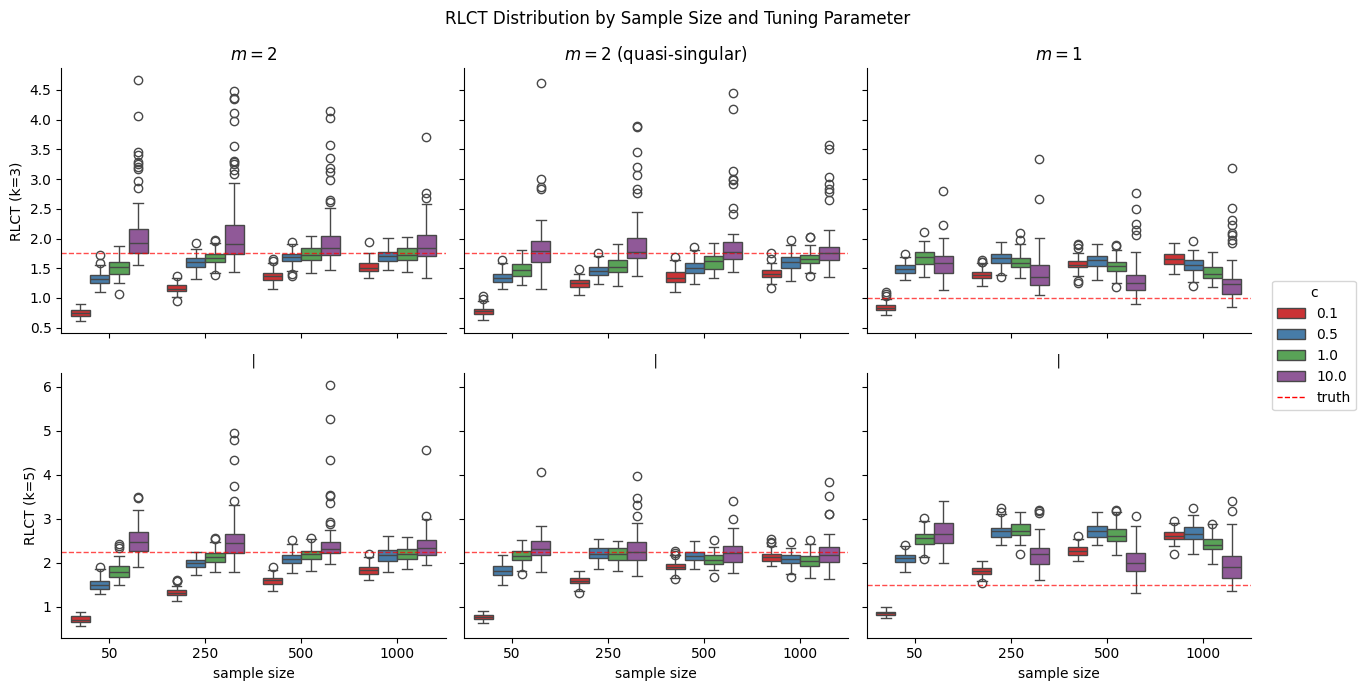

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# Compute true RLCT for each row
rlcthat_tunning_df['true_rlct'] = rlcthat_tunning_df.apply(
    lambda row: rlct_by_dsid(row['dsid'], row['k']), axis=1
)

# Compute squared error per row
rlcthat_tunning_df['sq_error'] = (rlcthat_tunning_df['rlct'] - rlcthat_tunning_df['true_rlct']) ** 2

# Label mapping for display
dsid_labels = {
    'regular': '$m=2$',
    'e-singular': '$m=2$ (quasi-singular)',
    'singular1': '$m=1$'
}

# --- Figure 1: RLCT Distribution ---
g1 = sns.FacetGrid(
    rlcthat_tunning_df,
    row='k',
    col='dsid',
    sharey='row',
    sharex=True,
    height=3.5,
    aspect=1.3
)

g1.map_dataframe(sns.boxplot, x='regime', y='rlct', hue='c', palette='Set1')

# Add true RLCT lines
for ax, (k_val, dsid_val) in zip(g1.axes.flat, [(k, d) for k in g1.row_names for d in g1.col_names]):
    true_val = rlct_by_dsid(dsid_val, k_val)
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1, alpha=0.7)

# Column titles with mapped labels
g1.set_titles(row_template='', col_template='')
for ax, dsid_val in zip(g1.axes[0], g1.col_names):
    ax.set_title(dsid_labels.get(dsid_val, dsid_val))

# Set x-axis label
g1.set_axis_labels('sample size', '')

# Row y-labels with k value
for ax, k_val in zip(g1.axes[:, 0], g1.row_names):
    ax.set_ylabel(f'RLCT (k={k_val})')

# Legend
handles, labels = g1.axes.flat[0].get_legend_handles_labels()
handles.append(Line2D([0], [0], color='red', linestyle='--', linewidth=1))
labels.append('truth')

for ax in g1.axes.flat:
    legend = ax.get_legend()
    if legend:
        legend.remove()

g1.figure.legend(handles, labels, title='c', loc='center right')

g1.figure.suptitle('RLCT Distribution by Sample Size and Tuning Parameter')
plt.tight_layout()
plt.subplots_adjust(right=0.92)
plt.show()

# Reset to default after (optional)
# plt.rcParams.update(plt.rcParamsDefault)

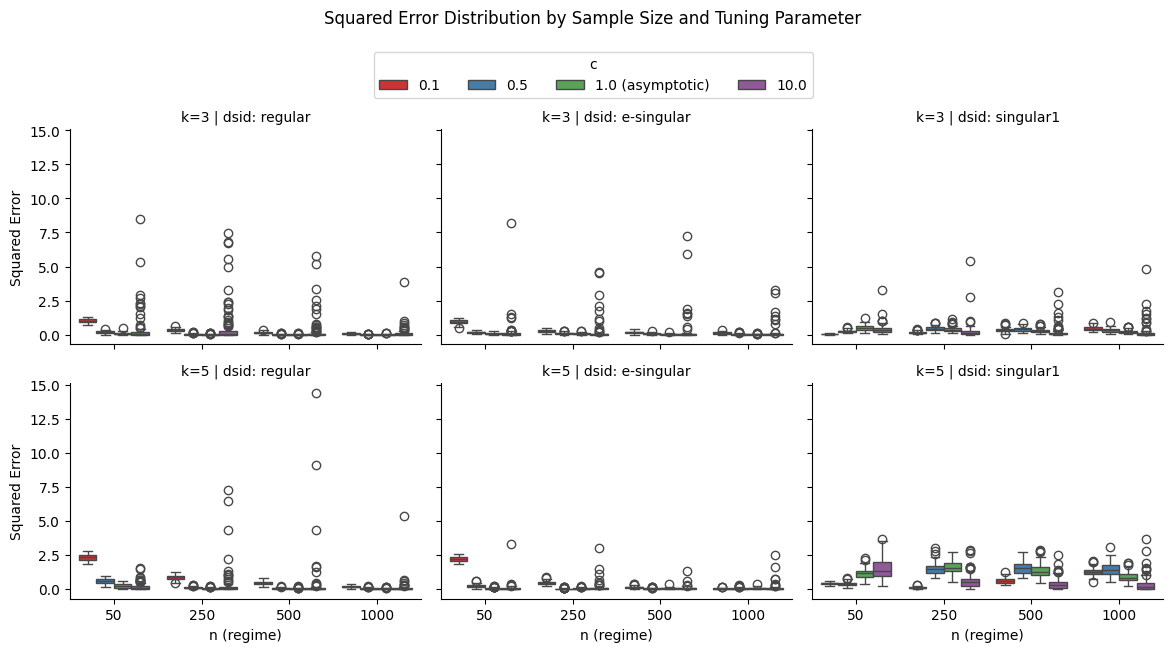

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Compute true RLCT for each row
rlcthat_tunning_df['true_rlct'] = rlcthat_tunning_df.apply(
    lambda row: rlct_by_dsid(row['dsid'], row['k']), axis=1
)

# Compute squared error per row
rlcthat_tunning_df['sq_error'] = (rlcthat_tunning_df['rlct'] - rlcthat_tunning_df['true_rlct']) ** 2

# --- Figure 2: Squared Error Distribution ---
g2 = sns.FacetGrid(
    rlcthat_tunning_df,
    row='k',
    col='dsid',
    sharey=True,  # share y across all subplots for alignment
    sharex=True,
    height=3,
    aspect=1.3
)

g2.map_dataframe(sns.boxplot, x='regime', y='sq_error', hue='c', palette='Set1')

# Remove legends from subplots and add single legend
handles, labels = g2.axes.flat[0].get_legend_handles_labels()

# Replace c=1 label with "1 (asymptotic)"
labels = [f'{label} (asymptotic)' if label == '1.0' or label == '1' else label for label in labels]

for ax in g2.axes.flat:
    legend = ax.get_legend()
    if legend:
        legend.remove()

g2.figure.legend(
    handles, 
    labels, 
    title='c', 
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(labels)
)

g2.set_axis_labels('n (regime)', 'Squared Error')
g2.set_titles(row_template='k={row_name}', col_template='dsid: {col_name}')
g2.figure.suptitle('Squared Error Distribution by Sample Size and Tuning Parameter', y=1.08)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

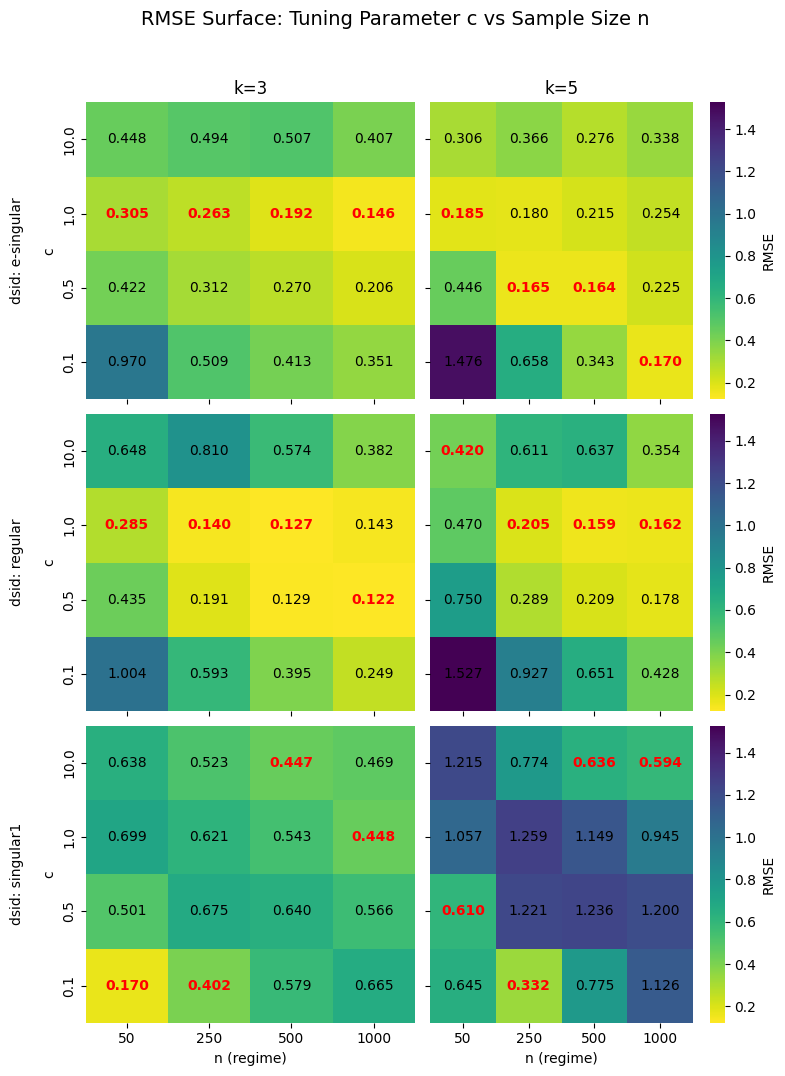

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Compute true RLCT for each row
rlcthat_tunning_df['true_rlct'] = rlcthat_tunning_df.apply(
    lambda row: rlct_by_dsid(row['dsid'], row['k']), axis=1
)

# Compute RMSE per (regime, c, k, dsid) group
def compute_rmse(group):
    return np.sqrt(((group['rlct'] - group['true_rlct'])**2).mean())

rmse_df = rlcthat_tunning_df.groupby(['regime', 'c', 'k', 'dsid']).apply(
    compute_rmse, include_groups=False
).reset_index(name='rmse')

# Get unique values for faceting
k_values = sorted(rmse_df['k'].unique())
dsid_values = sorted(rmse_df['dsid'].unique())

# Create figure with subplots - dsid on rows, k on columns
fig, axes = plt.subplots(
    nrows=len(dsid_values), 
    ncols=len(k_values), 
    figsize=(4 * len(k_values), 3.5 * len(dsid_values)),
    sharex=True,
    sharey=True
)

# Handle case of single row or column
if len(dsid_values) == 1:
    axes = axes.reshape(1, -1)
if len(k_values) == 1:
    axes = axes.reshape(-1, 1)

# Find global min/max for consistent colorbar
vmin = rmse_df['rmse'].min()
vmax = rmse_df['rmse'].max()

# Plot heatmaps
for i, dsid_val in enumerate(dsid_values):
    for j, k_val in enumerate(k_values):
        ax = axes[i, j]
        
        # Filter and pivot data
        subset = rmse_df[(rmse_df['k'] == k_val) & (rmse_df['dsid'] == dsid_val)]
        pivot = subset.pivot(index='c', columns='regime', values='rmse')
        pivot = pivot.sort_index(ascending=False)
        
        # Find minimum value per column (per regime/n)
        col_mins = pivot.min(axis=0)
        
        # Plot heatmap without annotations
        sns.heatmap(
            pivot, 
            ax=ax, 
            cmap='viridis_r',
            annot=False,
            vmin=vmin,
            vmax=vmax,
            cbar=(j == len(k_values) - 1),
            cbar_kws={'label': 'RMSE'} if j == len(k_values) - 1 else {}
        )
        
        # Add custom annotations with red for column minimum
        for row_idx, row_label in enumerate(pivot.index):
            for col_idx, col_label in enumerate(pivot.columns):
                val = pivot.loc[row_label, col_label]
                is_col_min = val == col_mins[col_label]
                ax.text(
                    col_idx + 0.5, 
                    row_idx + 0.5, 
                    f'{val:.3f}',
                    ha='center', 
                    va='center',
                    color='red' if is_col_min else 'black',
                    fontweight='bold' if is_col_min else 'normal',
                    fontsize=10
                )
        
        # Titles
        if i == 0:
            ax.set_title(f'k={k_val}')
        if j == 0:
            ax.set_ylabel(f'dsid: {dsid_val}\n\nc')
        else:
            ax.set_ylabel('')
        if i == len(dsid_values) - 1:
            ax.set_xlabel('n (regime)')
        else:
            ax.set_xlabel('')

fig.suptitle('RMSE Surface: Tuning Parameter c vs Sample Size n', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

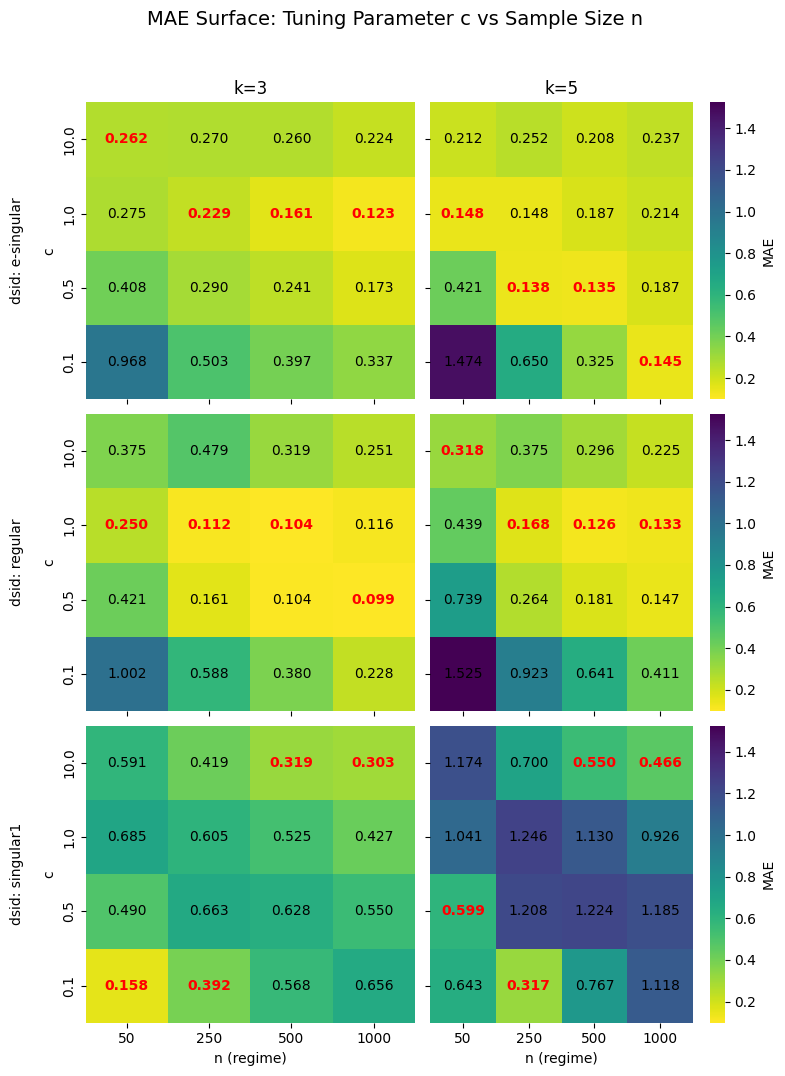

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Compute true RLCT for each row
rlcthat_tunning_df['true_rlct'] = rlcthat_tunning_df.apply(
    lambda row: rlct_by_dsid(row['dsid'], row['k']), axis=1
)

# Compute MAE per (regime, c, k, dsid) group
def compute_mae(group):
    return np.abs(group['rlct'] - group['true_rlct']).mean()

mae_df = rlcthat_tunning_df.groupby(['regime', 'c', 'k', 'dsid']).apply(
    compute_mae, include_groups=False
).reset_index(name='mae')

# Get unique values for faceting
k_values = sorted(mae_df['k'].unique())
dsid_values = sorted(mae_df['dsid'].unique())

# Create figure with subplots - dsid on rows, k on columns
fig, axes = plt.subplots(
    nrows=len(dsid_values), 
    ncols=len(k_values), 
    figsize=(4 * len(k_values), 3.5 * len(dsid_values)),
    sharex=True,
    sharey=True
)

# Handle case of single row or column
if len(dsid_values) == 1:
    axes = axes.reshape(1, -1)
if len(k_values) == 1:
    axes = axes.reshape(-1, 1)

# Find global min/max for consistent colorbar
vmin = mae_df['mae'].min()
vmax = mae_df['mae'].max()

# Plot heatmaps
for i, dsid_val in enumerate(dsid_values):
    for j, k_val in enumerate(k_values):
        ax = axes[i, j]
        
        # Filter and pivot data
        subset = mae_df[(mae_df['k'] == k_val) & (mae_df['dsid'] == dsid_val)]
        pivot = subset.pivot(index='c', columns='regime', values='mae')
        pivot = pivot.sort_index(ascending=False)
        
        # Find minimum value per column (per regime/n)
        col_mins = pivot.min(axis=0)
        
        # Plot heatmap without annotations
        sns.heatmap(
            pivot, 
            ax=ax, 
            cmap='viridis_r',
            annot=False,
            vmin=vmin,
            vmax=vmax,
            cbar=(j == len(k_values) - 1),
            cbar_kws={'label': 'MAE'} if j == len(k_values) - 1 else {}
        )
        
        # Add custom annotations with red for column minimum
        for row_idx, row_label in enumerate(pivot.index):
            for col_idx, col_label in enumerate(pivot.columns):
                val = pivot.loc[row_label, col_label]
                is_col_min = val == col_mins[col_label]
                ax.text(
                    col_idx + 0.5, 
                    row_idx + 0.5, 
                    f'{val:.3f}',
                    ha='center', 
                    va='center',
                    color='red' if is_col_min else 'black',
                    fontweight='bold' if is_col_min else 'normal',
                    fontsize=10
                )
        
        # Titles
        if i == 0:
            ax.set_title(f'k={k_val}')
        if j == 0:
            ax.set_ylabel(f'dsid: {dsid_val}\n\nc')
        else:
            ax.set_ylabel('')
        if i == len(dsid_values) - 1:
            ax.set_xlabel('n (regime)')
        else:
            ax.set_xlabel('')

fig.suptitle('MAE Surface: Tuning Parameter c vs Sample Size n', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()